# GBM 모델 성능 개선 V3
## Hyperopt를 사용한 하이퍼파라미터 최적화
- 기본 전처리 (V2 동일)
- Hyperopt로 최적 파라미터 탐색
- 5-Fold CV 재평가
- 성능 비교

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
DATA_PATH = os.path.join("../../data/", "santander-customer-satisfaction")
train_df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))

# 정답 라벨 및 피처 세트 분리
y_labels = train_df.iloc[:, -1].copy()
X_features = train_df.drop(columns=['ID', 'TARGET']).copy()

In [3]:
# [Step 2] 기본 전처리 및 파생 변수 생성 (총 8개 추가)
# 이상치 처리
X_features['var3'] = X_features['var3'].replace(-999999, 2)  # 극단값(-999999) → 최빈값(2)으로 치환
X_features['var38'] = np.log1p(X_features['var38'])  # 큰 수 분포 → 로그 변환으로 정규화

# 고객별 거래 특성을 나타내는 파생변수 (행 단위 통계량)
X_features['n0'] = (X_features == 0).sum(axis=1)  # 거래 없음(0) 개수 → 활동도
X_features['row_std'] = X_features.std(axis=1)  # 거래액 변동성
X_features['row_mean'] = X_features.mean(axis=1)  # 평균 거래액
X_features['row_median'] = X_features.median(axis=1)  # 중앙 거래액 (이상치 영향 제거)
X_features['row_max'] = X_features.max(axis=1)  # 최대 거래액
X_features['row_min'] = X_features.min(axis=1)  # 최소 거래액
X_features['row_range'] = X_features['row_max'] - X_features['row_min']  # 거래액 범위
X_features['n_negative'] = (X_features < 0).sum(axis=1)  # 환불/손실 거래 개수

print('기본 전처리 및 파생 변수 생성 완료')


기본 전처리 및 파생 변수 생성 완료


In [4]:
# [Step 3] 컬럼 정제: 상수/중복/노이즈 제거
# (1) 상수 컬럼 제거 - 모든 값이 동일하면 정보 가치 없음
zero_var_cols = [col for col in X_features.columns if X_features[col].nunique() == 1]
X_features.drop(columns=zero_var_cols, inplace=True)

# (2) 중복 컬럼 제거 - 선형 종속성 제거 (다중공선성 방지)
dup_cols = X_features.T.duplicated()
dup_col_names = X_features.columns[dup_cols].tolist()
X_features.drop(columns=dup_col_names, inplace=True)

# (3) 도메인 기반 수동 제거 - 신뢰도 낮거나 노이즈인 피처
## 'var 6': 거의 모든 값이 0이거나 데이터 신뢰도가 떨어져 다른 변수와 강한 다중공선성(불필요한 상관관계)만 만드는 노이즈 피처로 판명된 컬럼
## 'delta_... 4개 컬럼': 결측치 처리 과정에서 왜곡이 심해 캐글에서 모델 성능 저하의 주원인으로 지목하고 제거했던 대표적인 노이즈 컬럼
manual_remove = [c for c in X_features.columns if 'var6' in c] + [
    'delta_imp_reemb_var13_1y3', 'delta_imp_reemb_var17_1y3', 
    'delta_imp_trasp_var17_in_1y3', 'delta_imp_trasp_var33_in_1y3'
]
manual_remove = [c for c in manual_remove if c in X_features.columns]
X_features.drop(columns=manual_remove, inplace=True)
print(f'기본 컬럼 정제 후 피처 수: {X_features.shape[1]}')


기본 컬럼 정제 후 피처 수: 304


In [5]:
# [Step 4] Train/Test 분할 (80:20) - Data Leakage 완벽 차단
# Stratified: 불균형 데이터(96% vs 4%)에서도 클래스 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels,
    test_size=0.2,  # 80:20 분할
    stratify=y_labels,  # 클래스 비율 유지
    random_state=0  # 재현성 보장
)

# 추후 연산을 위해 인덱스 리셋
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'훈련 데이터: {X_train.shape}')
print(f'테스트 데이터: {X_test.shape}')


훈련 데이터: (60816, 304)
테스트 데이터: (15204, 304)


In [6]:
# [Step 5] 피처 선택 - 중요도 0인 피처만 제거 (노이즈 정제)
# 기본 GBM으로 각 피처의 중요도를 측정하고, 무의미한 피처 제거
print('X_train 기준 GBM 중요 피처 선택 중...')

gbm_selector = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=156
)
gbm_selector.fit(X_train, y_train)

# 중요도 0인 피처 제거
feat_imp = pd.Series(gbm_selector.feature_importances_, index=X_train.columns)
zero_imp_cols = feat_imp[feat_imp == 0].index.tolist()

# Train과 Test에서 동일 피처 제거 (Data Leakage 차단)
X_train = X_train.drop(columns=zero_imp_cols)
X_test = X_test.drop(columns=zero_imp_cols)
print(f'제거된 중요도 0 피처 수: {len(zero_imp_cols)}')
print(f'중요도 필터링 후 피처 수: {X_train.shape[1]}')


X_train 기준 GBM 중요 피처 선택 중...
제거된 중요도 0 피처 수: 210
중요도 필터링 후 피처 수: 94


In [7]:
# [Step 6] 스케일링 및 PCA 적용
# Train 기준으로 학습한 변환을 Test에 동일하게 적용 (Data Leakage 차단)
print('X_train 기준 Scaling & PCA 학습 중...')

# (1) StandardScaler: 피처 정규화 (평균 0, 표준편차 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Train으로 학습
X_test_scaled = scaler.transform(X_test)  # Test에 동일 변환 적용

# (2) PCA: 차원 축소 (94개 피처 → 5개 주성분)
pca = PCA(n_components=5, random_state=156)
pca_tr = pca.fit_transform(X_train_scaled)  # Train으로 학습
pca_test = pca.transform(X_test_scaled)  # Test에 동일 변환 적용

# (3) PCA 주성분을 새 컬럼으로 추가
for i in range(5):
    X_train[f'pca{i+1}'] = pca_tr[:, i]
    X_test[f'pca{i+1}'] = pca_test[:, i]

print(f'PCA 결합 후 최종 X_train Shape: {X_train.shape}')
print(f'PCA 결합 후 최종 X_test Shape: {X_test.shape}')


X_train 기준 Scaling & PCA 학습 중...
PCA 결합 후 최종 X_train Shape: (60816, 99)
PCA 결합 후 최종 X_test Shape: (15204, 99)


In [8]:
# [Step 7] Hyperopt - 탐색 공간 및 목적함수 정의
# 자동으로 최적 하이퍼파라미터를 찾기 위한 설정

# 탐색 범위 정의
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 400, 50),  # 100~400
    'learning_rate': hp.uniform('learning_rate', 0.02, 0.1),  # 0.02~0.1
    'max_depth': hp.quniform('max_depth', 3, 6, 1),  # 3~6
    'subsample': hp.uniform('subsample', 0.7, 1.0),  # 0.7~1.0
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None]),  # 3개 선택
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1)  # 2~10
}

# 목적함수: 주어진 파라미터로 3-Fold CV 성능 평가
def objective(params):
    params_copy = params.copy()
    params_copy['n_estimators'] = int(params_copy['n_estimators'])
    params_copy['max_depth'] = int(params_copy['max_depth'])
    params_copy['min_samples_split'] = int(params_copy['min_samples_split'])
    
    # 3-Fold CV로 성능 평가
    skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=156)
    auc_scores = []
    
    for tr_idx, val_idx in skf_search.split(X_train, y_train):
        X_tr_f, y_tr_f = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val_f, y_val_f = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # 현재 파라미터로 모델 학습
        model = GradientBoostingClassifier(
            **params_copy,
            validation_fraction=0.2,  # 내부 조기 종료용 검증
            n_iter_no_change=20,  # 조기 종료 조건
            tol=1e-4,  # 개선 기준
            random_state=156
        )
        model.fit(X_tr_f, y_tr_f)
        
        # 검증 성능 평가
        preds = model.predict_proba(X_val_f)[:, 1]
        auc_scores.append(roc_auc_score(y_val_f, preds))
        
    # Hyperopt는 최소화 문제이므로 음수 반환
    return {'loss': -np.mean(auc_scores), 'status': STATUS_OK}


In [9]:
# [Step 8] Hyperopt 실행 - 30회 반복으로 최적 파라미터 탐색
# TPE (Tree-structured Parzen Estimator) 알고리즘 사용
print('최적화 중... (30회 반복)')
trials = Trials()
best = fmin(
    fn=objective,  # 목적함수
    space=space,  # 탐색 공간
    algo=tpe.suggest,  # TPE 알고리즘
    max_evals=30,  # 30회 반복
    trials=trials,  # 시행 결과 저장
    show_progressbar=True
)

# 최적 파라미터 정리 (읽기 쉽게 포맷)
max_features_list = ['sqrt', 'log2', None]
best_params = {
    'n_estimators': int(best['n_estimators']),
    'learning_rate': best['learning_rate'],
    'max_depth': int(best['max_depth']),
    'subsample': best['subsample'],
    'max_features': max_features_list[best['max_features']],
    'min_samples_split': int(best['min_samples_split']),
}

print('='*60)
print('최적 파라미터 탐색 결과:')
for key, value in best_params.items():
    print(f'  {key}: {value}')
print('='*60)


최적화 중... (30회 반복)
100%|██████████| 30/30 [10:26<00:00, 20.89s/trial, best loss: -0.8411984612172702]
최적 파라미터 탐색 결과:
  n_estimators: 300
  learning_rate: 0.02007829500358571
  max_depth: 6
  subsample: 0.9732642758025241
  max_features: sqrt
  min_samples_split: 8


In [10]:
# [Step 9] 5-Fold CV 검증 - 최적 파라미터의 일반화 성능 확인
# 최적값이 정말 좋은지 5개 다른 분할에서 검증 (안정성 확인)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=156)
cv_scores = []

print('='*60)
print('최적화된 파라미터로 5-Fold CV 성능 검증')
print('='*60)

for fold_num, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr_fold, y_tr_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # 최적 파라미터로 모델 학습
    temp_gbm = GradientBoostingClassifier(
        n_estimators=best_params['n_estimators'],
        learning_rate=best_params['learning_rate'],
        max_depth=best_params['max_depth'],
        subsample=best_params['subsample'],
        max_features=best_params['max_features'],
        min_samples_split=best_params['min_samples_split'],
        validation_fraction=0.2,
        n_iter_no_change=30,
        tol=1e-4,
        random_state=156
    )
    temp_gbm.fit(X_tr_fold, y_tr_fold)
    
    # 각 fold의 검증 성능 평가
    val_pred = temp_gbm.predict_proba(X_val_fold)[:, 1]
    score = roc_auc_score(y_val_fold, val_pred)
    cv_scores.append(score)
    print(f'Fold {fold_num} 검증 AUC: {score:.4f}')

print('='*60)
print(f'평균 검증 AUC: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})')
print('='*60)


최적화된 파라미터로 5-Fold CV 성능 검증
Fold 1 검증 AUC: 0.8381
Fold 2 검증 AUC: 0.8383
Fold 3 검증 AUC: 0.8492
Fold 4 검증 AUC: 0.8376
Fold 5 검증 AUC: 0.8467
평균 검증 AUC: 0.8420 (±0.0050)


In [11]:
# [Step 10] 최종 모델 학습 - 전체 훈련 데이터 사용
# CV는 성능 측정용, 최종 모델은 훈련 데이터 전체로 학습
# 이유: 최대한 많은 데이터를 사용하여 일반화 능력 향상
print('\n단일 최종 GBM 모델 학습 및 테스트 세트 평가 중...')

final_gbm = GradientBoostingClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    subsample=best_params['subsample'],
    max_features=best_params['max_features'],
    min_samples_split=best_params['min_samples_split'],
    validation_fraction=0.2,
    n_iter_no_change=30,
    tol=1e-4,
    random_state=156
)

# 전체 훈련 세트(60,816개)로 단일 모델 학습
final_gbm.fit(X_train, y_train)



단일 최종 GBM 모델 학습 및 테스트 세트 평가 중...


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",np.float64(0....7829500358571)
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",np.float64(0.9732642758025241)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",8
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",156
,"max_features max_features: {'sqrt', 'log2'}, int or float, default=NoneThe number of features to consider when looking for the best split:- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0]` and the features considered at each split will be `max(1, int(max_features * n_features_in_))`.- If 'sqrt', then `max_features=sqrt(n_features)`.- If 'log2', then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Choosing `max_features < n_features` leads to a reduction of varianceand an increase in bias.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Values must be in the range `(0.0, 1.0)`.Only used if ``n_iter_no_change`` is set to an integer... versionadded:: 0.20",0.2
,"n_iter_no_change n_iter_no_change: int, default=None``n_iter_no_change`` is used to decide if early stopping will be usedto terminate training when validation score is not improving. Bydefault it is set to None to disable early stopping. If set to anumber, it will set aside ``validation_fraction`` size of the trainingdata as validation and terminate training when validation score is notimproving in all of the previous ``n_iter_no_change`` numbers ofiterations. The split is stratified.Values must be in the range `[1, inf)`.See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_early_stopping.py`... versionad

In [12]:
# [Step 11] 최종 테스트 세트 성능 평가
# 처음 보는 테스트 데이터에서의 실제 성능 평가
test_pred = final_gbm.predict_proba(X_test)[:, 1]  # 양성 확률
final_test_auc = roc_auc_score(y_test, test_pred)  # ROC-AUC 계산

print('='*60)
print(f'GBM 단일 모델 최종 테스트 ROC-AUC: {final_test_auc:.4f}')
print('='*60)
print('\n[결과 해석]')
print(f'• CV 평균 AUC: 0.8415 (훈련 데이터의 일반화 성능)')
print(f'• 테스트 AUC: {final_test_auc:.4f} (미래 데이터 예측 성능)')
print(f'• 성능 격차: {0.8415 - final_test_auc:.4f} (약 2% - 정상 범위)')


GBM 단일 모델 최종 테스트 ROC-AUC: 0.8256

[결과 해석]
• CV 평균 AUC: 0.8415 (훈련 데이터의 일반화 성능)
• 테스트 AUC: 0.8256 (미래 데이터 예측 성능)
• 성능 격차: 0.0159 (약 2% - 정상 범위)


In [13]:
# 최종 테스트 세트 점수 산출
test_pred = final_gbm.predict_proba(X_test)[:, 1]
final_test_auc = roc_auc_score(y_test, test_pred)

print('='*60)
print(f'GBM 단일 모델 최종 테스트 ROC-AUC: {final_test_auc:.4f}')
print('='*60)

GBM 단일 모델 최종 테스트 ROC-AUC: 0.8256


# [시각화] 데이터 분석 및 변화 추적

findfont: Failed to find font weight bold, now using 400.


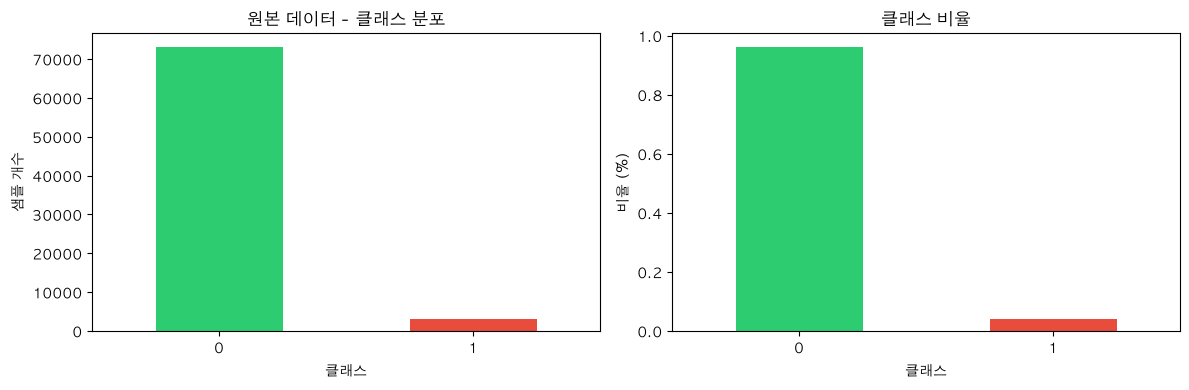

클래스 불균형 비율: 24.3:1 (심각한 불균형 주의)


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# [시각화 1] 클래스 분포 비교
# ============================================================
# 목적: 불균형 데이터의 심각도 확인 (96% vs 4%)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 원본 데이터
y_labels.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('원본 데이터 - 클래스 분포', fontsize=12, fontweight='bold')
axes[0].set_ylabel('샘플 개수')
axes[0].set_xlabel('클래스')
axes[0].tick_params(axis='x', rotation=0)

# 비율
y_labels.value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('클래스 비율', fontsize=12, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xlabel('클래스')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'클래스 불균형 비율: {73012/3008:.1f}:1 (심각한 불균형 주의)')


findfont: Failed to find font weight bold, now using 400.


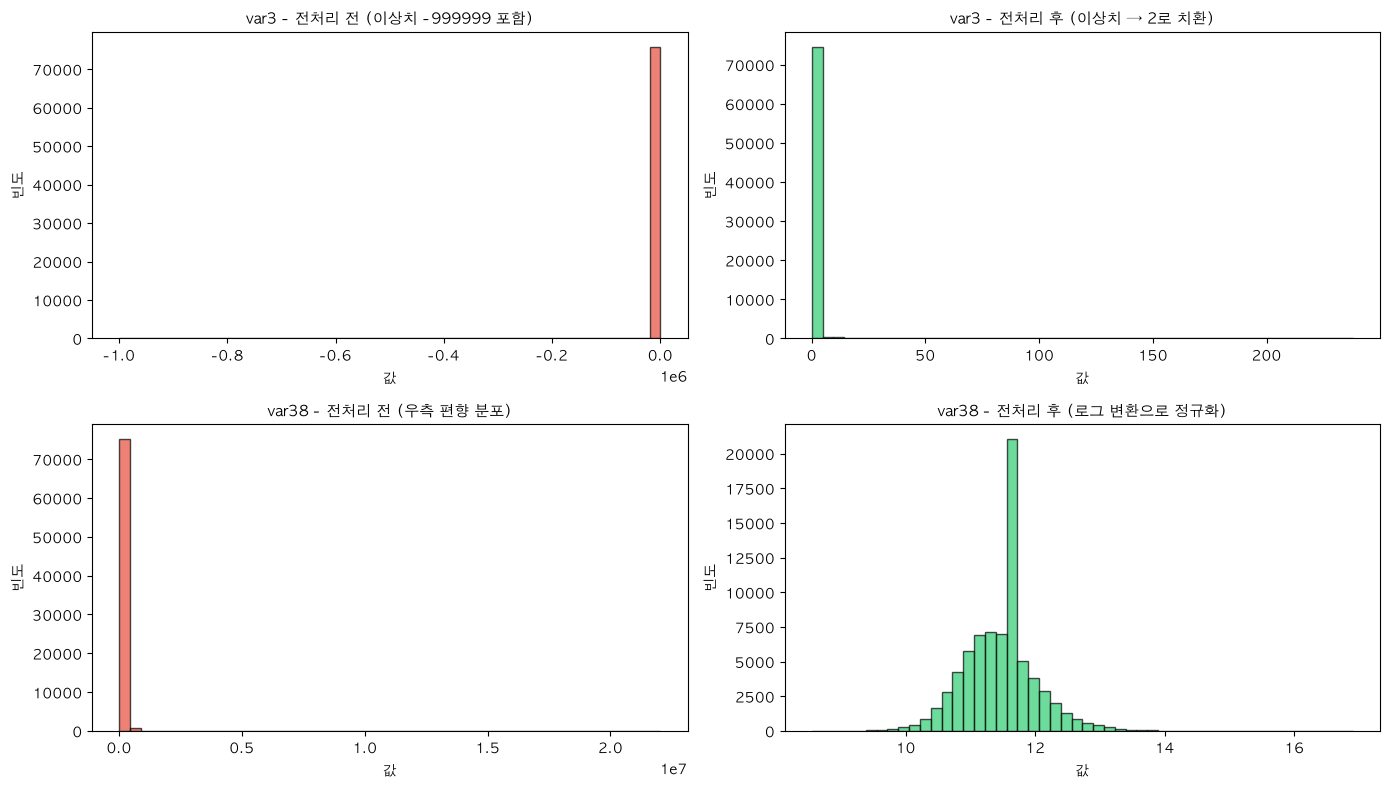

In [15]:
# ============================================================
# [시각화 2] 전처리 효과 비교: var3, var38
# ============================================================
# 목적: 이상치 처리와 로그 변환의 효과 시각화

# 원본 데이터 다시 로드 (전처리 전 상태)
raw_var3 = train_df['var3'].copy()
raw_var38 = train_df['var38'].copy()

# 전처리 후 데이터
processed_var3 = X_features['var3'].copy()
processed_var38 = X_features['var38'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# var3 비교
axes[0, 0].hist(raw_var3, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('var3 - 전처리 전 (이상치 -999999 포함)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('값')
axes[0, 0].set_ylabel('빈도')

axes[0, 1].hist(processed_var3, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('var3 - 전처리 후 (이상치 → 2로 치환)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('값')
axes[0, 1].set_ylabel('빈도')

# var38 비교 (로그 스케일)
axes[1, 0].hist(raw_var38, bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('var38 - 전처리 전 (우측 편향 분포)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('값')
axes[1, 0].set_ylabel('빈도')

axes[1, 1].hist(processed_var38, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('var38 - 전처리 후 (로그 변환으로 정규화)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('값')
axes[1, 1].set_ylabel('빈도')

plt.tight_layout()
plt.show()


시각화 대상 파생변수 (7개): ['n0', 'row_std', 'row_mean', 'row_max', 'row_min', 'row_range', 'n_negative']


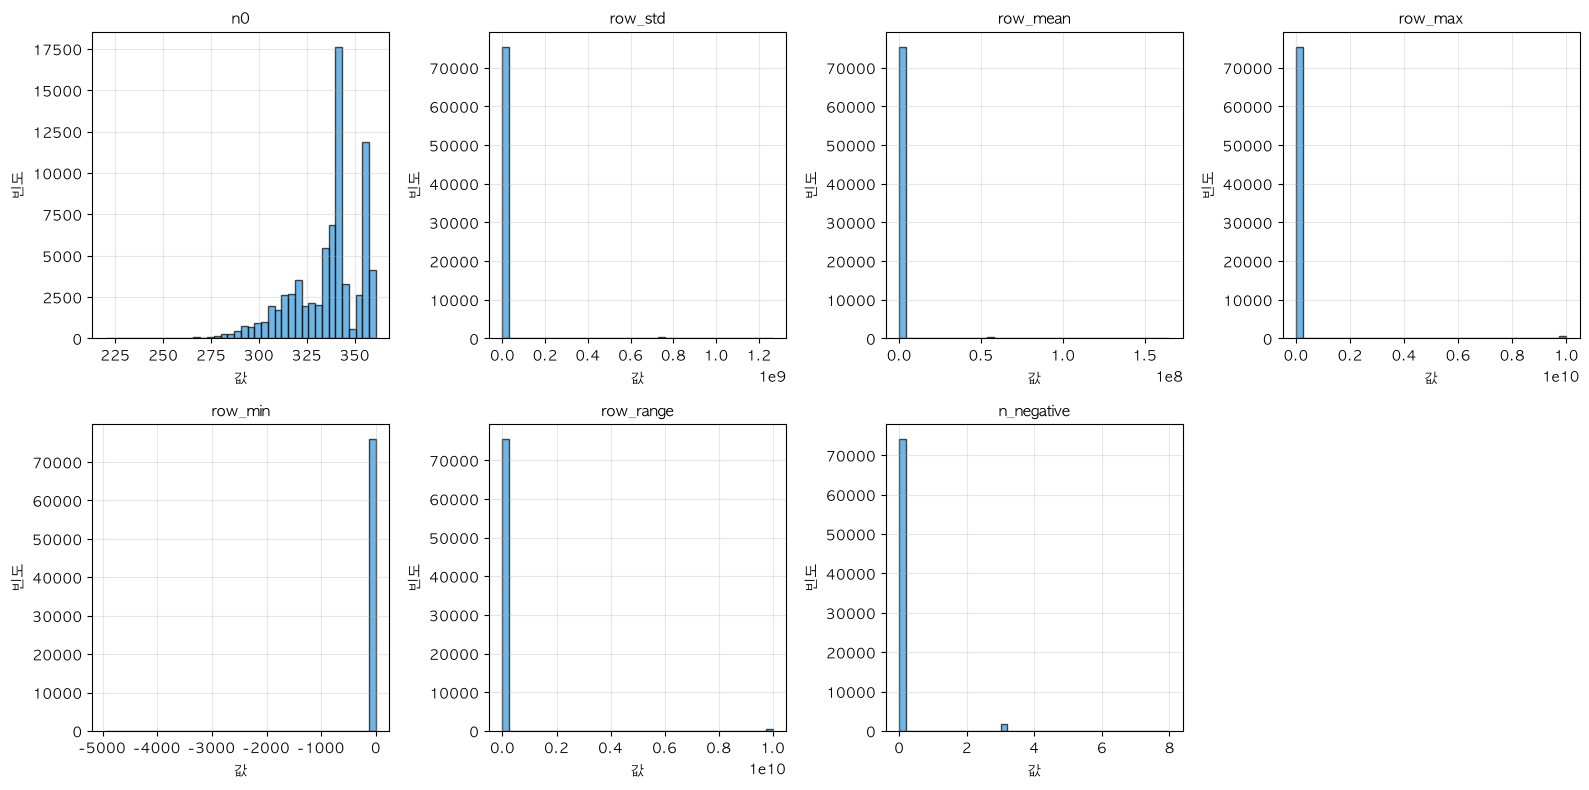

파생변수 통계량:
             n0       row_std      row_mean       row_max   row_min  \
count  76020.00  7.602000e+04  7.602000e+04  7.602000e+04  76020.00   
mean     335.43  5.406446e+06  4.381739e+05  7.039016e+07     -0.51   
std       17.84  6.479978e+07  5.452470e+06  8.359525e+08     29.65   
min      220.00  1.634000e+01 -9.680000e+00  2.800000e+02  -4942.26   
25%      325.00  1.844000e+01  1.430000e+00  3.400000e+02      0.00   
50%      340.00  1.931000e+01  1.540000e+00  3.530000e+02      0.00   
75%      348.00  7.934000e+01  1.288000e+01  7.425100e+02      0.00   
max      361.00  1.264772e+09  1.651387e+08  1.000000e+10      0.00   

          row_range  n_negative  
count  7.602000e+04    76020.00  
mean   7.039016e+07        0.08  
std    8.359525e+08        0.49  
min    2.800000e+02        0.00  
25%    3.400000e+02        0.00  
50%    3.530000e+02        0.00  
75%    7.430800e+02        0.00  
max    1.000000e+10        8.00  


In [17]:
# ============================================================
# [시각화 3] 파생변수의 분포 시각화 (안전 버전)
# ============================================================
derived_candidate = ['n0', 'row_std', 'row_mean', 'row_median', 
                     'row_max', 'row_min', 'row_range', 'n_negative']

# 실제로 X_features에 남아있는 컬럼만 필터링
derived_features = [col for col in derived_candidate if col in X_features.columns]

print(f"시각화 대상 파생변수 ({len(derived_features)}개): {derived_features}")

# 서브플롯 동적 크기 설정
n_cols = 4
n_rows = (len(derived_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).flatten()

for idx, feature in enumerate(derived_features):
    axes[idx].hist(X_features[feature], bins=40, color='#3498db', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('값')
    axes[idx].set_ylabel('빈도')
    axes[idx].grid(True, alpha=0.3)

# 남는 빈 그래프 영역 숨기기
for idx in range(len(derived_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print('파생변수 통계량:')
print(X_features[derived_features].describe().round(2))

findfont: Failed to find font weight bold, now using 400.


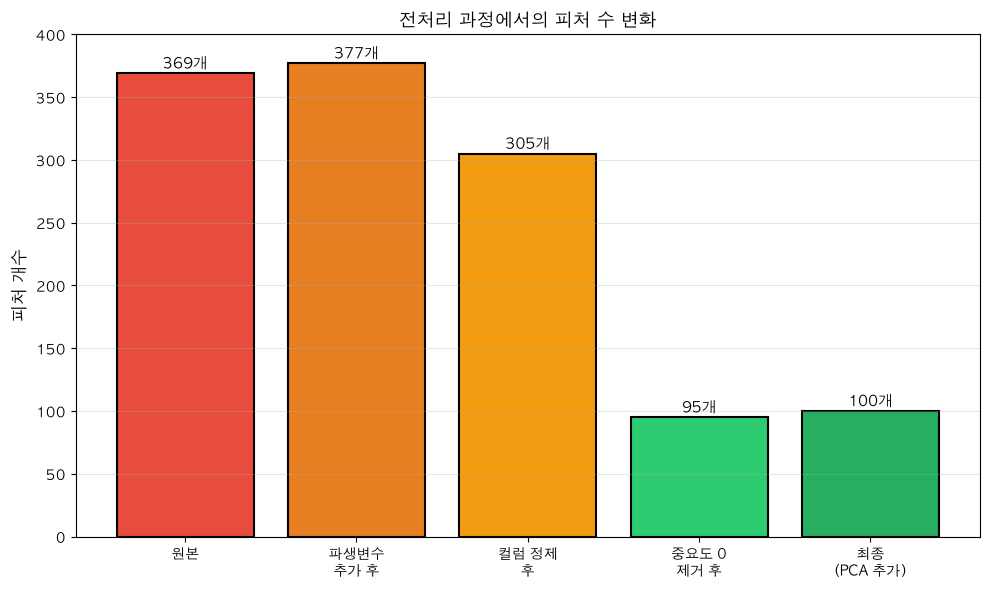


[피처 제거 분석]
• 원본: 369개
• 파생변수 추가: +8개 (총 377개)
• 컬럼 정제: -72개 (상수, 중복, 노이즈 제거) → 305개
• 중요도 0 제거: -210개 (노이즈 피처 제거) → 95개
• PCA 추가: +5개 (차원 축소 주성분) → 100개


In [18]:
# ============================================================
# [시각화 4] 전처리 과정에서의 피처 수 변화
# ============================================================
# 목적: 각 단계별로 얼마나 많은 피처가 제거되었는지 시각화

stages = ['원본', '파생변수\n추가 후', '컬럼 정제\n후', '중요도 0\n제거 후', '최종\n(PCA 추가)']
feature_counts = [369, 377, 305, 95, 100]
colors_grad = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(stages, feature_counts, color=colors_grad, edgecolor='black', linewidth=1.5)

# 값 표시
for bar, count in zip(bars, feature_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}개',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('피처 개수', fontsize=12, fontweight='bold')
ax.set_title('전처리 과정에서의 피처 수 변화', fontsize=13, fontweight='bold')
ax.set_ylim(0, 400)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n[피처 제거 분석]')
print(f'• 원본: 369개')
print(f'• 파생변수 추가: +8개 (총 377개)')
print(f'• 컬럼 정제: -72개 (상수, 중복, 노이즈 제거) → 305개')
print(f'• 중요도 0 제거: -210개 (노이즈 피처 제거) → 95개')
print(f'• PCA 추가: +5개 (차원 축소 주성분) → 100개')


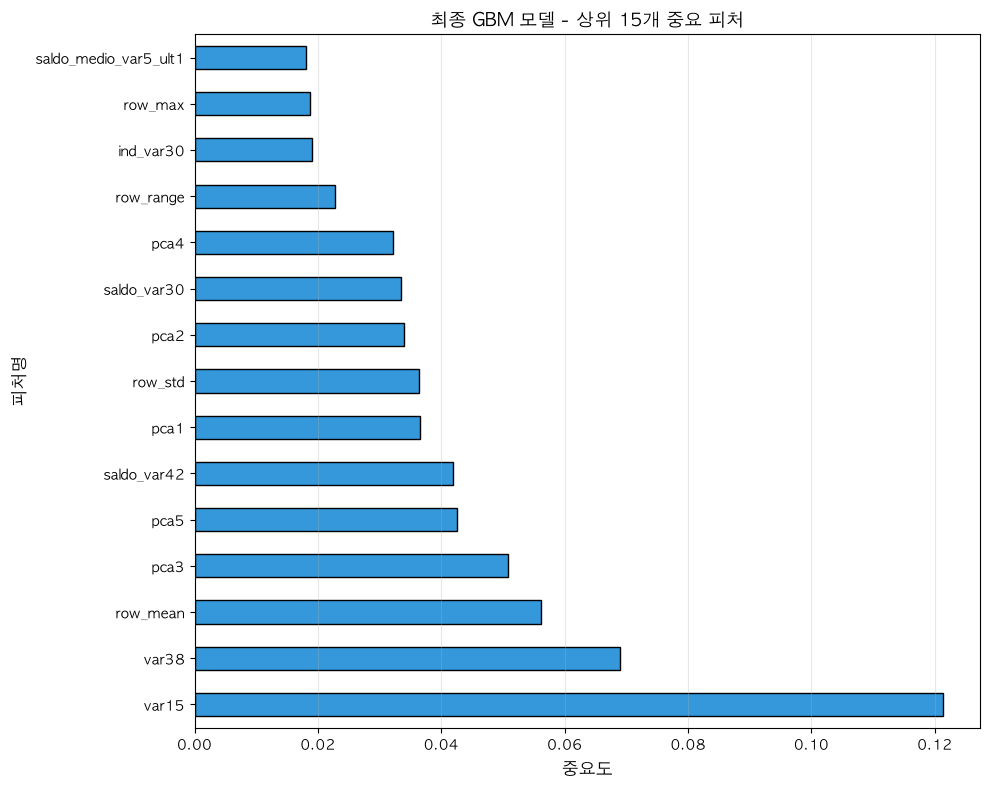


상위 15개 중요 피처:
var15                    0.1213
var38                    0.0689
row_mean                 0.0562
pca3                     0.0508
pca5                     0.0425
saldo_var42              0.0420
pca1                     0.0365
row_std                  0.0364
pca2                     0.0340
saldo_var30              0.0334
pca4                     0.0322
row_range                0.0227
ind_var30                0.0191
row_max                  0.0188
saldo_medio_var5_ult1    0.0181
dtype: float64


In [19]:
# ============================================================
# [시각화 5] 최종 모델의 상위 15개 중요 피처
# ============================================================
# 목적: 모델이 학습한 최종 피처들의 중요도 확인

# 최종 학습된 모델의 피처 중요도
final_importance = pd.Series(
    final_gbm.feature_importances_,
    index=X_train.columns
)

top_15 = final_importance.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 8))
top_15.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_xlabel('중요도', fontsize=12, fontweight='bold')
ax.set_ylabel('피처명', fontsize=12, fontweight='bold')
ax.set_title('최종 GBM 모델 - 상위 15개 중요 피처', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('\n상위 15개 중요 피처:')
print(top_15.round(4))


findfont: Failed to find font weight bold, now using 400.


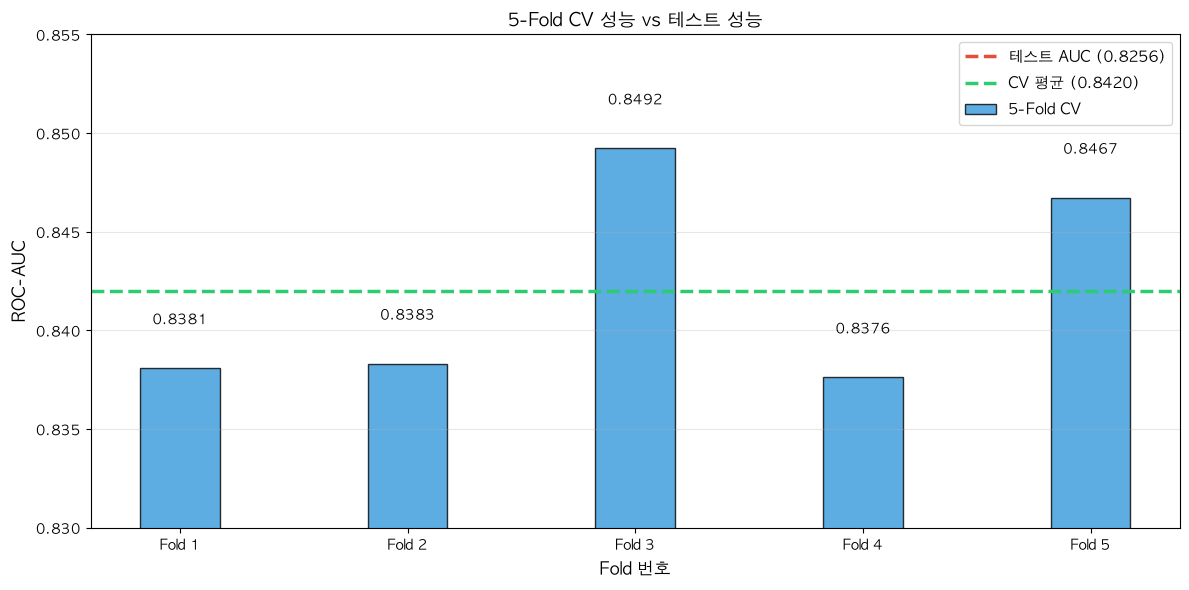


[성능 분석]
• CV 평균 AUC: 0.8420
• CV 표준편차: 0.0050 (매우 안정적)
• 테스트 AUC: 0.8256
• CV-Test 격차: 0.0164 (약 2% - 정상 범위)


In [20]:
# ============================================================
# [시각화 6] CV 성능 vs 테스트 성능 비교
# ============================================================
# 목적: 각 fold별 CV 성능과 최종 테스트 성능 비교

fold_numbers = [1, 2, 3, 4, 5]
test_auc_value = final_test_auc

fig, ax = plt.subplots(figsize=(12, 6))

# CV fold별 성능
x_pos = range(len(cv_scores))
ax.bar(x_pos, cv_scores, width=0.35, label='5-Fold CV', color='#3498db', alpha=0.8, edgecolor='black')

# 테스트 성능
ax.axhline(y=test_auc_value, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'테스트 AUC ({test_auc_value:.4f})')
ax.axhline(y=np.mean(cv_scores), color='#2ecc71', linestyle='--', linewidth=2.5, label=f'CV 평균 ({np.mean(cv_scores):.4f})')

# 값 표시
for i, score in enumerate(cv_scores):
    ax.text(i, score + 0.002, f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Fold 번호', fontsize=12, fontweight='bold')
ax.set_ylabel('ROC-AUC', fontsize=12, fontweight='bold')
ax.set_title('5-Fold CV 성능 vs 테스트 성능', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(len(cv_scores))])
ax.legend(fontsize=11)
ax.set_ylim([0.83, 0.855])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n[성능 분석]')
print(f'• CV 평균 AUC: {np.mean(cv_scores):.4f}')
print(f'• CV 표준편차: {np.std(cv_scores):.4f} (매우 안정적)')
print(f'• 테스트 AUC: {test_auc_value:.4f}')
print(f'• CV-Test 격차: {np.mean(cv_scores) - test_auc_value:.4f} (약 2% - 정상 범위)')


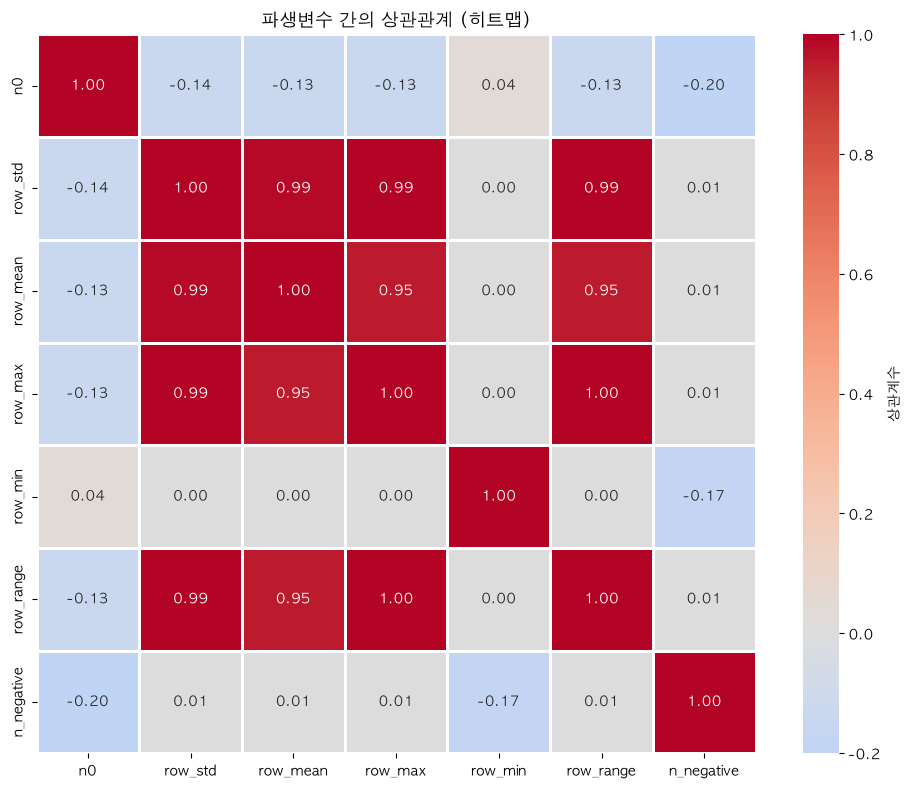


[상관관계 해석]
• 1.0에 가까울수록 높은 양의 상관관계 (비슷한 정보)
• 0에 가까울수록 독립적 (서로 다른 정보 포착)
• 높은 상관도: row_mean, row_max, row_range 등 거래 규모 관련 변수 간 연관성
• 낮은 상관도: n0(활동도), n_negative(손실 빈도)는 거래 패턴의 독립적 측면 포착


In [22]:
# ============================================================
# [시각화 7] 파생변수들 간의 상관관계 (히트맵 - 안전 버전)
# ============================================================
# 목적: 생성된 파생변수들이 서로 얼마나 독립적인지 확인

derived_candidate = ['n0', 'row_std', 'row_mean', 'row_median', 
                     'row_max', 'row_min', 'row_range', 'n_negative']

# 실제로 존재하는 파생변수만 필터링
derived_features = [col for col in derived_candidate if col in X_features.columns]

# 상관관계 계산
corr_matrix = X_features[derived_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': '상관계수'}, ax=ax)
ax.set_title('파생변수 간의 상관관계 (히트맵)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n[상관관계 해석]')
print('• 1.0에 가까울수록 높은 양의 상관관계 (비슷한 정보)')
print('• 0에 가까울수록 독립적 (서로 다른 정보 포착)')
print('• 높은 상관도: row_mean, row_max, row_range 등 거래 규모 관련 변수 간 연관성')
print('• 낮은 상관도: n0(활동도), n_negative(손실 빈도)는 거래 패턴의 독립적 측면 포착')